#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Overview

In [108]:
# Load the dataset
data = pd.read_csv("Real estate.csv")

In [110]:
# Printing first five rows
data.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [112]:
# Identifying the column names and their data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


# Data Inconsistency
To find inconsistency in columns we need to find irregularities in the data.
There should not be missing values and all values of a columns should have same datatype

In [115]:
# Finding any null values 
data.isnull()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
409,False,False,False,False,False,False,False,False
410,False,False,False,False,False,False,False,False
411,False,False,False,False,False,False,False,False
412,False,False,False,False,False,False,False,False


In [117]:
data.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [119]:
# Checking duplicate values
data.duplicated().sum()

0

Since there are no missing and inconsistent values so the dataset is consistent

# 2. Statistical Summary
Describe function provides metrics such as count, mean, standard deviation, minimum, and maximum.

In [123]:
data['X2 house age'].describe()

count    414.000000
mean      17.712560
std       11.392485
min        0.000000
25%        9.025000
50%       16.100000
75%       28.150000
max       43.800000
Name: X2 house age, dtype: float64

In [125]:
data['X2 house age'].median()

16.1

In [127]:
data['Y house price of unit area'].describe()

count    414.000000
mean      37.980193
std       13.606488
min        7.600000
25%       27.700000
50%       38.450000
75%       46.600000
max      117.500000
Name: Y house price of unit area, dtype: float64

In [129]:
data['Y house price of unit area'].median()

38.45

In [131]:
data['X3 distance to the nearest MRT station'].describe()

count     414.000000
mean     1083.885689
std      1262.109595
min        23.382840
25%       289.324800
50%       492.231300
75%      1454.279000
max      6488.021000
Name: X3 distance to the nearest MRT station, dtype: float64

In [133]:
data['X4 number of convenience stores'].describe()

count    414.000000
mean       4.094203
std        2.945562
min        0.000000
25%        1.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: X4 number of convenience stores, dtype: float64

In [135]:
data['X4 number of convenience stores'].median()

4.0

# Analysis
In a symmetric distribution, the mean and median are nearly equal. 
If there is a noticeable difference between them, the distribution is skewed:  
- **Mean > Median**: Indicates a right (positive) skew. 
- **Mean < Median**: Indicates a left (negative) skew. 
In this dataset, since the mean and median are approximately equal, the distribution is likely symmetric.   
The maximum and minimum values are helpful in identifying outliers or extreme values at either end of the range

# 3. Data Cleaning:
Data cleaning involves preparing raw data for analysis by addressing inaccuracies, inconsistencies, and errors.   
This process includes handling missing values, standardizing data formats, and ensuring consistency throughout the dataset.   
By improving data quality, this step ensures the dataset is accurate and reliable for analysis and informed decision-making.

In [139]:
data.isnull()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
409,False,False,False,False,False,False,False,False
410,False,False,False,False,False,False,False,False
411,False,False,False,False,False,False,False,False
412,False,False,False,False,False,False,False,False


In [141]:
data.duplicated().sum()

0

Our dataset has no missing or duplicate values.  
If inconsistent data were present, it could be addressed as follows:  
- **Missing Values**: Missing entries can be handled by removing the rows entirely or filling them with appropriate values, such as the mean, median, or a default value.  
- **Duplicate Entries**: Duplicates can be identified and removed to avoid redundancy and ensure data integrity.

# 4. Univaraite Analysis:
Univariate analysis focuses on analyzing a single variable in a dataset to understand its distribution, patterns, and key characteristics.
It includes calculating metrics like mean, median, variance, and visualizing data through histograms or box plots.
This helps identify trends, outliers, and data quality issues, aiding in exploratory data analysis.

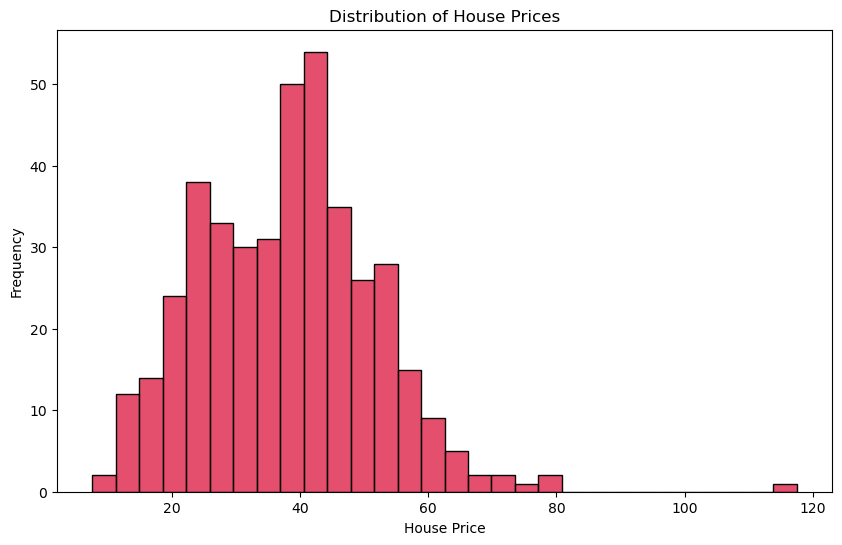

In [146]:
# Plot the distribution of house prices 
plt.figure(figsize=(10, 6))

house_prices = data['Y house price of unit area']

sns.histplot(house_prices,  bins=30, color='crimson', edgecolor='black')

plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

Text(0, 0.5, 'Frequency')

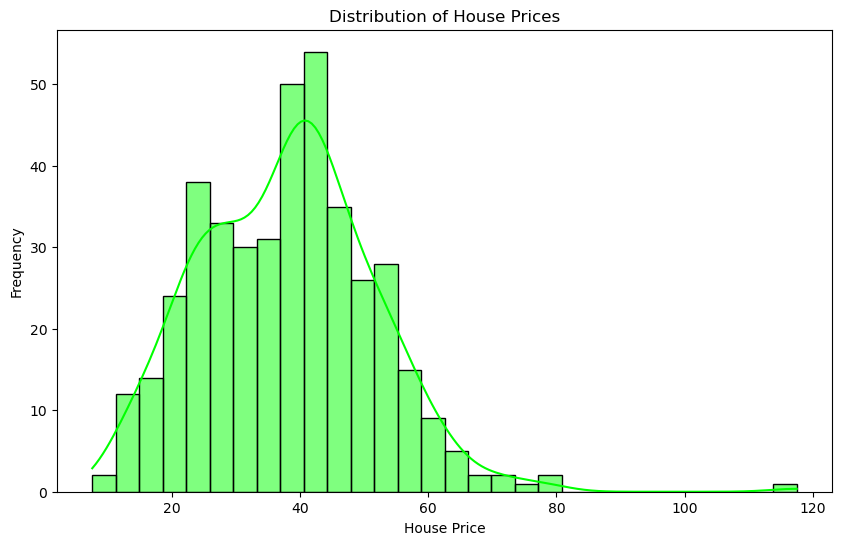

In [147]:
# Plot the distribution of house prices 

plt.figure(figsize=(10, 6))

house_prices = data['Y house price of unit area']

sns.histplot(house_prices, kde = True, bins=30, color='lime', edgecolor='black')

plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')

In [149]:
from scipy.stats import skew

# Calculate skewness
house_prices_skewness = skew(house_prices)
print(f"Skewness of house prices: {house_prices_skewness}")

Skewness of house prices: 0.5976770142537495


# Skewness Analysis:
The extended tail on the right side indicates that there are a few houses with extremely high prices, but they occur infrequently. 
This suggests a near balance in housing affordability. 
The data appears to be symmetric, without significant skewness. 
Therefore, The given data is not skewed.

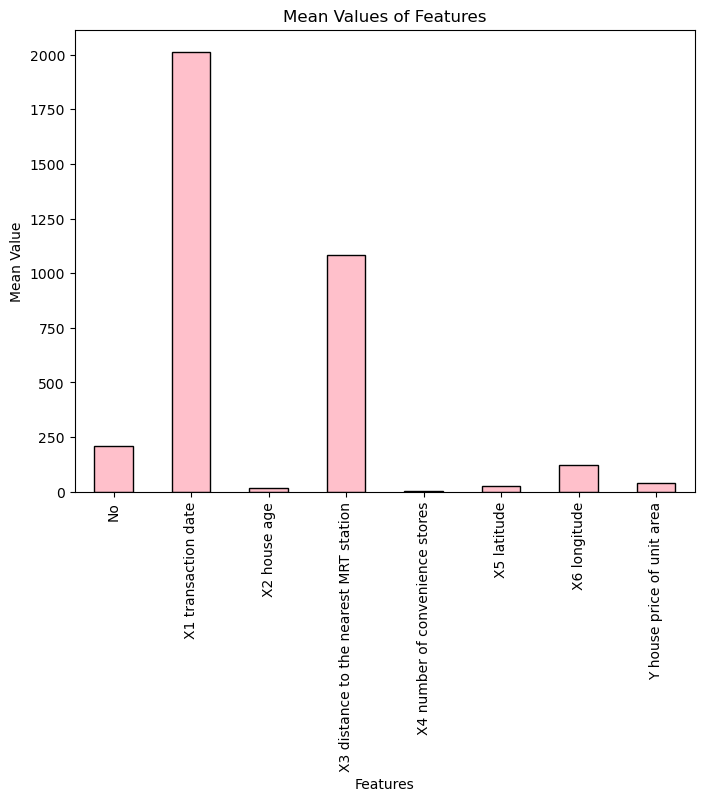

In [153]:
# Example of a bar plot for the mean of features
data.mean().plot(kind='bar', figsize=(8, 6), color='pink', edgecolor='black')
plt.title('Mean Values of Features')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.show()

# 5. Feature Exploration

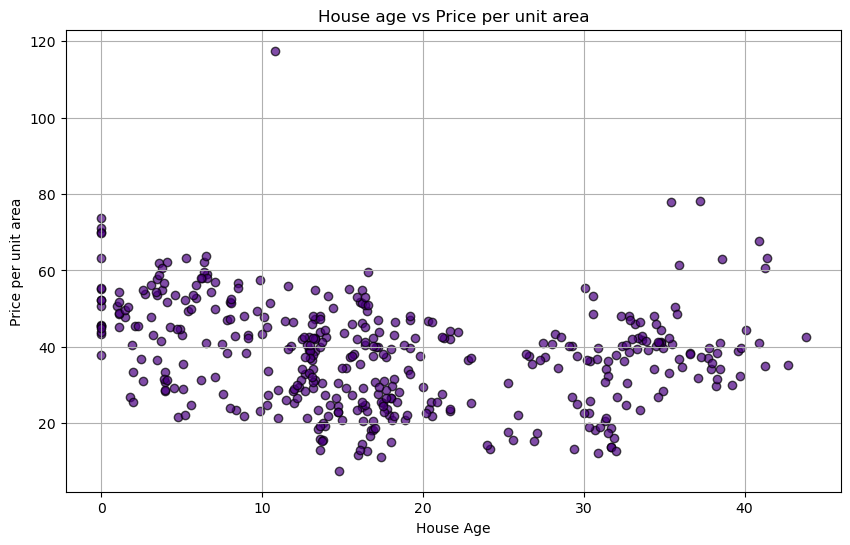

In [160]:
# Relationship between House age vs Price per unit area
column = ['X2 house age']
target = ['Y house price of unit area']
plt.figure(figsize=(10, 6))
plt.scatter(data[column], data[target], alpha=0.7, edgecolors='k',color='indigo')
plt.title('House age vs Price per unit area', fontsize=12)
plt.xlabel("House Age", fontsize=10)
plt.ylabel("Price per unit area", fontsize=10)
plt.grid(True)

plt.show()

# Observation:
 House prices exhibit a slight decline with increasing age, as older properties typically have lower prices. However, there is significant variability, with some older houses still fetching high prices despite the general trend.

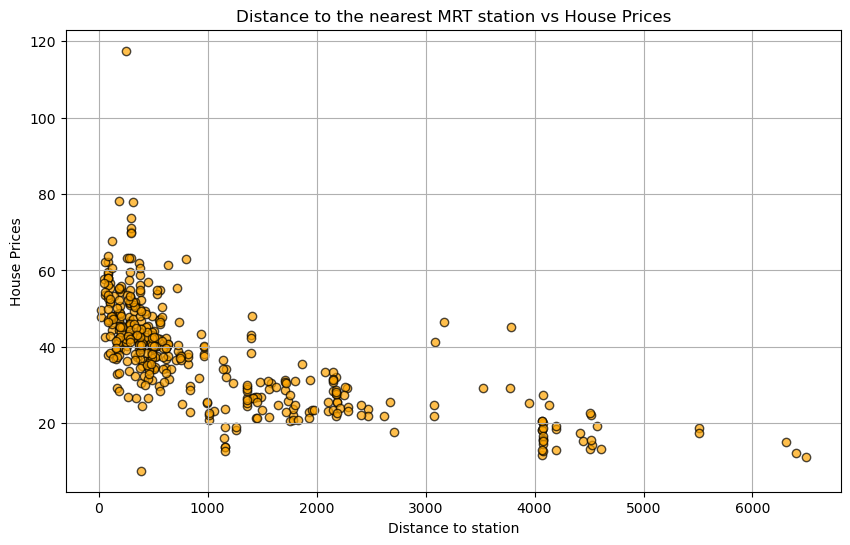

In [182]:
# Relationship between Distance to the nearest MRT station vs House Prices
column2 = ['X3 distance to the nearest MRT station']
target = ['Y house price of unit area']


plt.figure(figsize=(10, 6))

plt.scatter(data[column2], data[target], alpha=0.7, edgecolors='k', color = 'orange')
plt.title('Distance to the nearest MRT station vs House Prices', fontsize=12)
plt.xlabel('Distance to station', fontsize=10)
plt.ylabel('House Prices', fontsize=10)
plt.grid(True)

plt.show()

# Observation:
 A negative correlation is observed, where house prices tend to decrease as the distance from the MRT station increases. Properties located near MRT stations are generally priced higher, while those situated farther away experience lower prices. This suggests that proximity to public transportation increases demand and value.

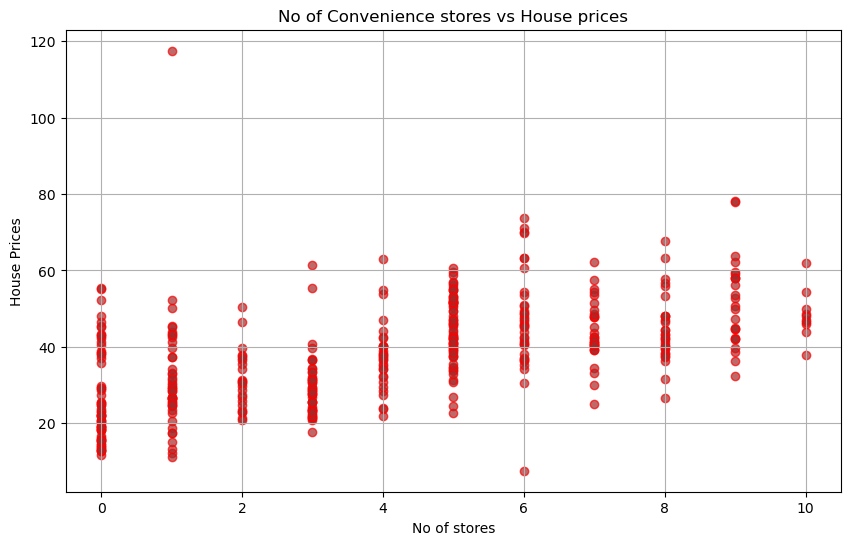

In [185]:
#Reltionship between No of Convenience stores vs House prices
column3 = ['X4 number of convenience stores']
target = ['Y house price of unit area']

plt.figure(figsize=(10, 6))

plt.scatter(data[column3], data[target], alpha=0.7, edgecolors='red', color = 'brown')
plt.title('No of Convenience stores vs House prices', fontsize=12)
plt.xlabel('No of stores', fontsize=10)
plt.ylabel('House Prices', fontsize=10)
plt.grid(True)

plt.show()

# Observation:
A positive correlation is evident, with areas that have more convenience stores generally experiencing higher house prices. However, the relationship is not strictly linear, and there is significant variability in the data points.

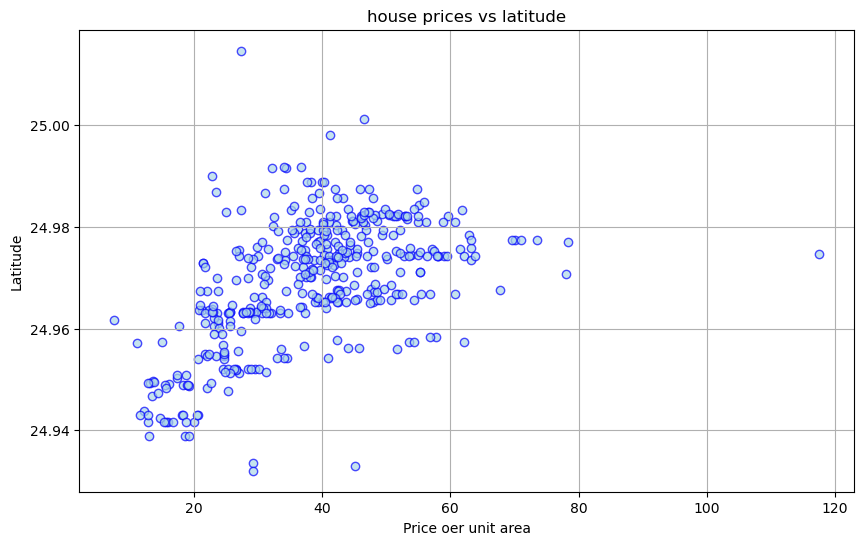

In [188]:
# Relationship between house prices vs latitude
column4 = ['Y house price of unit area']
target = ['X5 latitude']

plt.figure(figsize=(10, 6))

plt.scatter(data[column4], data[target], alpha=0.7, edgecolors='blue', color = 'lightblue')
plt.title('house prices vs latitude', fontsize=12)
plt.xlabel('Price oer unit area', fontsize=10)
plt.ylabel('Latitude', fontsize=10)
plt.grid(True)

plt.show()

# Observation:
There is a subtle upward trend, where house prices tend to increase with higher latitudes. A concentration of data points is observed around specific latitudes (between 24.96 and 24.98), suggesting the presence of popular or densely populated areas. This indicates that house prices could be affected by location-specific factors associated with latitude.

# SUBMITTED BY:
Name - Khushi<br>
Sap Id - 500122966<br>
Roll No - R21422306<br>
Batch - 3 AI/ML